In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split , cross_val_score , validation_curve , GridSearchCV
from sklearn.neighbors import KNeighborsClassifier


In [4]:
iris = load_iris()
X = iris.data
y = iris.target

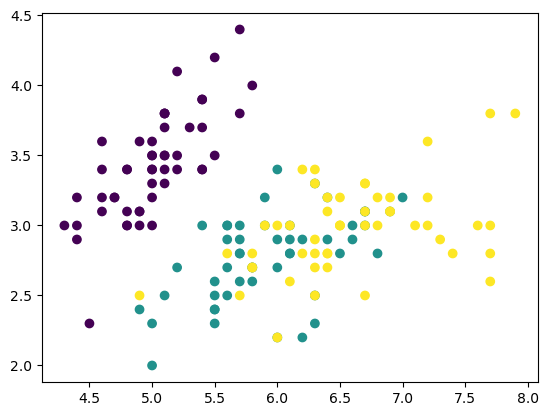

In [5]:
plt.scatter( X[:,0], X[:,1] , c = y  )

In [6]:
X_train , X_test ,  Y_train  , Y_test = train_test_split(X , y  , test_size=0.2)

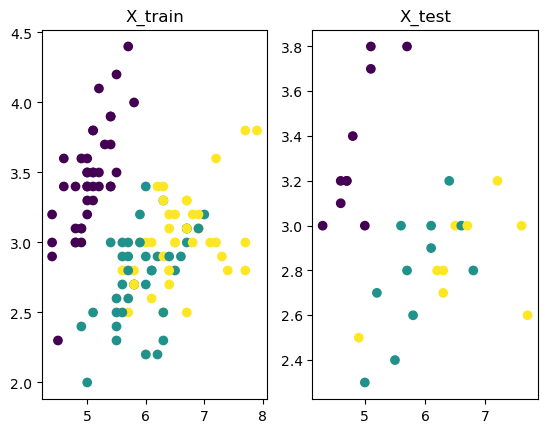

In [7]:
plt.Figure(figsize=(15,4))
plt.subplot(121)
plt.title("X_train")
plt.scatter( X_train[:,0], X_train[:,1] , c = Y_train  )

plt.subplot(122)
plt.title("X_test")
plt.scatter( X_test[:,0], X_test[:,1] , c = Y_test  )

In [8]:
model = KNeighborsClassifier(n_neighbors=1)
model.fit(X_train , Y_train)
print("Train score " , model.score(X_train , Y_train))
print("Test score " , model.score(X_test , Y_test))

Train score  1.0
Test score  0.9333333333333333


In [9]:
cross_val_score(KNeighborsClassifier() , X_train , Y_train , cv=5 , scoring='accuracy').mean()


0.9583333333333334

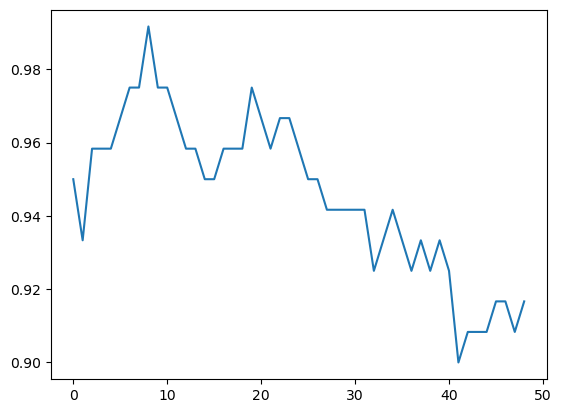

In [10]:
my_train_score = []
for k in range(1,50):
    my_train_score.append(cross_val_score(KNeighborsClassifier(k) , X_train , Y_train , cv=5 , scoring='accuracy').mean())

plt.plot(my_train_score)
    

# autre manier de le faire avec validation_curve

In [11]:
k = np.arange(1,50)
train_scores, val_scores = validation_curve(model, X_train, Y_train, param_name='n_neighbors', param_range=k, cv=5)

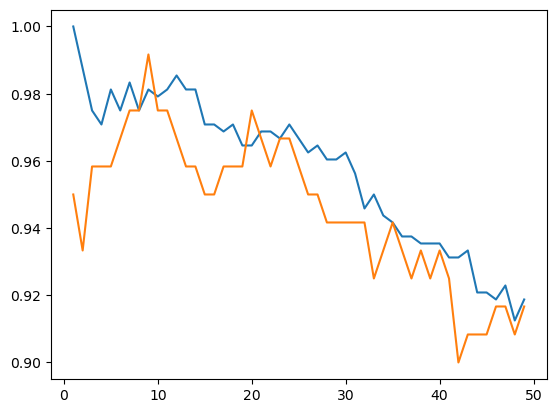

In [12]:
plt.figure()
plt.plot(k,train_scores.mean(axis=1))
plt.plot(k,val_scores.mean(axis=1))

In [13]:
mes_parametre = {
    'n_neighbors': np.arange(1,20),
    'metric' : [ 'euclidean' , 'manhattan' ]
}

my_grid = GridSearchCV( KNeighborsClassifier() , mes_parametre , cv=5 )

my_grid.fit( X_train , Y_train )


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19])})

In [14]:
print('mon best score est : ' , my_grid.best_score_)

mon best score est :  0.9916666666666668


In [15]:
print('mes meilleurs paramtres sont : ' , my_grid.best_params_)

mes meilleurs paramtres sont :  {'metric': 'euclidean', 'n_neighbors': 9}


In [16]:
print('mon best score est : ' , my_grid.best_estimator_)

mon best score est :  KNeighborsClassifier(metric='euclidean', n_neighbors=9)


In [17]:
#pour sauvegader notre model 
meilleur_model = my_grid.best_estimator_

In [18]:
meilleur_model.score(X_test , Y_test)

0.9

In [19]:
from sklearn.metrics import confusion_matrix

In [20]:
confusion_matrix( Y_test , meilleur_model.predict( X_test ) )

array([[10,  0,  0],
       [ 0, 11,  0],
       [ 0,  3,  6]], dtype=int64)

In [21]:
from sklearn.model_selection import learning_curve , GroupKFold

In [22]:
cv = GroupKFold(5).get_n_splits(X , y , groups=X[:,0])
N , train_score , vali_scores = learning_curve( KNeighborsClassifier() , X_train , Y_train , train_sizes=np.linspace(0.1 ,1.0 , 10 ) , cv=cv ) 

In [23]:
print(N) # N est le nombre d'element pour chaque pourcenetage de decoupage de  1 a 100

[ 9 19 28 38 48 57 67 76 86 96]


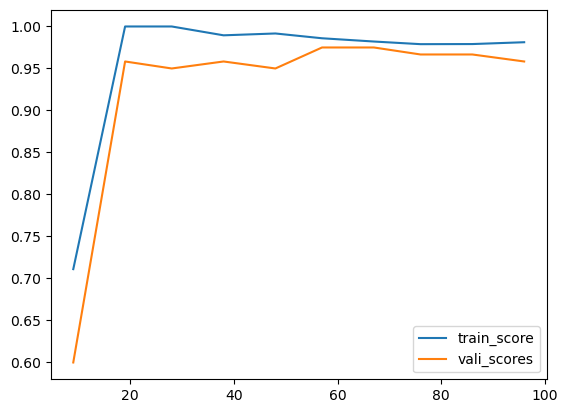

In [24]:
plt.plot( N , train_score.mean(axis=1) , label = 'train_score')
plt.plot( N , vali_scores.mean(axis=1) , label = 'vali_scores' )
plt.legend()

# PRE-PROCESSING

## Encodage


#### --Ordinale 

permet associer chaque categorier d'une variable a une valeur numerique 

In [25]:
from sklearn.preprocessing import LabelEncoder
## ce module permet de transformer une seul variable 

In [26]:
encodage =  LabelEncoder()
y = np.array(['chat' , 'chien' , 'mouton' , 'chat' , 'coq' , 'mouton'])

In [27]:
encodage.fit(y)
encodage.classes_ 


array(['chat', 'chien', 'coq', 'mouton'], dtype='<U6')

In [28]:
encodage.transform(y) # pour transformer chaque chaine a une valeur numerique 

array([0, 1, 3, 0, 2, 3])

In [29]:
# on peux faire les deux en meme temps
resultat_de_ma_transformation = encodage.fit_transform(y)

In [30]:
##pour inverser la transformation on peux utiliser ""inverse_transform""
encodage.inverse_transform(resultat_de_ma_transformation)

array(['chat', 'chien', 'mouton', 'chat', 'coq', 'mouton'], dtype='<U6')

In [31]:
# cette methode ne êrmet pas de convertire toutes les type de variable 
# mieux c'est d'utiliser OrdinalEncoder a la place de lebalEncoder

#### --Binaire 

In [32]:
from sklearn.preprocessing import LabelBinarizer 

In [36]:
mon_encodage = LabelBinarizer()
resultat_de_ma_transformation = mon_encodage.fit_transform(y) # permet de transformer sous forme de table 
resultat_de_ma_transformation

array([[1, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 0, 1],
       [1, 0, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 1]])